# Stores Exploratory Data Analysis (EDA)


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style


# Find the project root containing pyproject.toml
root = Path.cwd()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

from configs.config import RAW_DIR

## 1. Basic Structure
Check shape, dtypes, and duplicate `store_nbr` (each store must be a unique row).

In [2]:
stores = pd.read_csv(RAW_DIR / 'stores.csv')

print(f"Shape: {stores.shape}")
print(f"\nColumns: {list(stores.columns)}")
print(f"\nDtypes:\n{stores.dtypes}")
print(f"\nMissing values:\n{stores.isnull().sum()}")

n_duplicate_store_nbr = stores['store_nbr'].duplicated().sum()
print(f"\nDuplicate store_nbr count: {n_duplicate_store_nbr}")
print(f"store_nbr is unique key: {stores['store_nbr'].is_unique}")

Shape: (54, 5)

Columns: ['store_nbr', 'city', 'state', 'type', 'cluster']

Dtypes:
store_nbr     int64
city         object
state        object
type         object
cluster       int64
dtype: object

Missing values:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

Duplicate store_nbr count: 0
store_nbr is unique key: True


## 2. Distribution by city, state, type, cluster

In [3]:
print("Store count by city:")
print(stores['city'].value_counts())

print("\nStore count by state:")
print(stores['state'].value_counts())

print("\nStore count by type:")
print(stores['type'].value_counts())

print("\nStore count by cluster:")
print(stores['cluster'].value_counts().sort_index())

Store count by city:
city
Quito            18
Guayaquil         8
Cuenca            3
Santo Domingo     3
Latacunga         2
Machala           2
Manta             2
Ambato            2
Cayambe           1
Riobamba          1
Ibarra            1
Salinas           1
Puyo              1
Guaranda          1
Quevedo           1
Babahoyo          1
Daule             1
Playas            1
Loja              1
Libertad          1
Esmeraldas        1
El Carmen         1
Name: count, dtype: int64

Store count by state:
state
Pichincha                         19
Guayas                            11
Azuay                              3
Santo Domingo de los Tsachilas     3
Manabi                             3
Los Rios                           2
Cotopaxi                           2
Tungurahua                         2
El Oro                             2
Bolivar                            1
Imbabura                           1
Chimborazo                         1
Pastaza                            

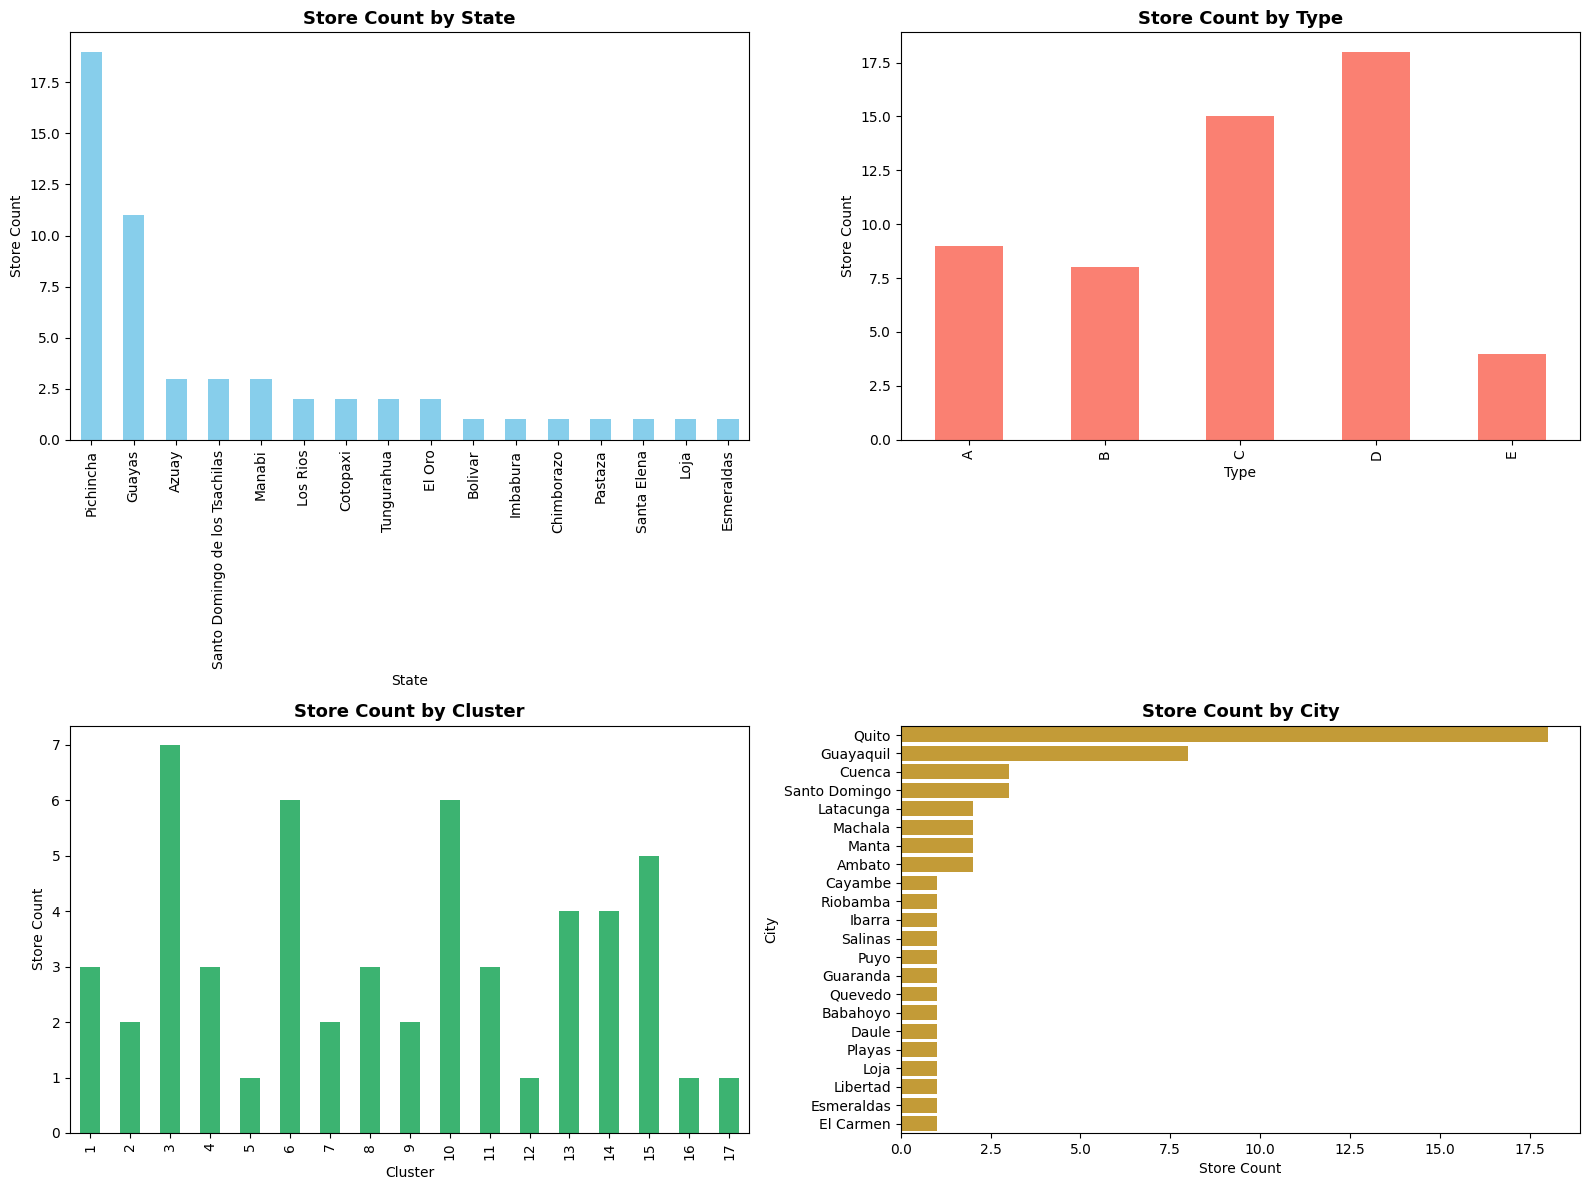

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

stores['state'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Store Count by State', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('State')
axes[0, 0].set_ylabel('Store Count')

stores['type'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Store Count by Type', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Type')
axes[0, 1].set_ylabel('Store Count')

stores['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Store Count by Cluster', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Store Count')

sns.countplot(data=stores, y='city', order=stores['city'].value_counts().index, ax=axes[1, 1], color='goldenrod')
axes[1, 1].set_title('Store Count by City', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Store Count')
axes[1, 1].set_ylabel('City')

plt.tight_layout()
plt.show()

In [5]:
print("Crosstab Type x Cluster:")
print(pd.crosstab(stores['type'], stores['cluster']))

Crosstab Type x Cluster:
cluster  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17
type                                                                       
A         0   0   0   0   1   0   0   0   0   0   3   0   0   4   0   0   1
B         0   0   0   0   0   6   0   0   0   1   0   0   0   0   0   1   0
C         0   0   7   0   0   0   2   0   0   0   0   1   0   0   5   0   0
D         3   2   0   3   0   0   0   3   2   1   0   0   4   0   0   0   0
E         0   0   0   0   0   0   0   0   0   4   0   0   0   0   0   0   0


## 3. Check: each city belongs to exactly 1 state


In [6]:
city_state_nunique = stores.groupby('city')['state'].nunique()
max_state_per_city = city_state_nunique.max()

print(f"Max number of states a single city belongs to: {max_state_per_city}")
print(f"Check city_state_nunique.max() == 1: {max_state_per_city == 1}")

if max_state_per_city > 1:
    print("\nCities belonging to multiple states:")
    print(city_state_nunique[city_state_nunique > 1])
else:
    print("\nNo city belongs to more than 1 state.")

Max number of states a single city belongs to: 1
Check city_state_nunique.max() == 1: True

No city belongs to more than 1 state.


## 4. String cross-check


In [8]:
holidays = pd.read_csv(RAW_DIR / 'holidays_events.csv')

locale_names = set(holidays['locale_name'].unique())
cities = set(stores['city'].unique())
states = set(stores['state'].unique())

unmatched_locale = locale_names - cities - states - {'Ecuador'}
cities_without_local_holiday = cities - locale_names
states_without_holiday = states - locale_names

print(f"Number of unique locale_name values in holidays_events.csv: {len(locale_names)}")
print(f"locale_name not matching any city/state/'Ecuador' (expected empty): {unmatched_locale}")
print(f"\nCities in stores.csv not appearing in locale_name: {sorted(cities_without_local_holiday)}")
print(f"States in stores.csv not appearing in locale_name: {sorted(states_without_holiday)}")

Number of unique locale_name values in holidays_events.csv: 24
locale_name not matching any city/state/'Ecuador' (expected empty): set()

Cities in stores.csv not appearing in locale_name: ['Babahoyo', 'Daule', 'Playas']
States in stores.csv not appearing in locale_name: ['Azuay', 'Bolivar', 'Chimborazo', 'El Oro', 'Guayas', 'Los Rios', 'Manabi', 'Pastaza', 'Pichincha', 'Tungurahua']
